## 8. Analysis and Next Steps

**Which model performed better?** Based on the metrics table above, compare the F1-scores rather
than accuracy alone — accuracy can look deceptively good on datasets where one class is more
common, while F1 balances precision and recall together.

**Cost of errors in this context:** A **false negative** here means predicting someone didn't
survive when they actually did — in a real triage/rescue-priority system, this is the more
costly error, since it could mean overlooking someone who needed help. A **false positive** means
predicting survival when the person didn't — less costly here, but still worth minimizing.

**Limitations:**
- Logistic Regression assumes roughly linear relationships between features and the outcome —
  it may miss more complex interactions (e.g., how age and class jointly affect survival).
- The Decision Tree, especially without limiting `max_depth`, can overfit — memorizing training
  data patterns that don't generalize to new passengers.

**Next steps to improve performance:**
1. **Hyperparameter tuning** with `GridSearchCV` to find the best `max_depth`, `C` (regularization
   strength), etc.
2. **Handle class imbalance** (if present) using techniques like SMOTE (synthetic oversampling) or
   class-weighting (`class_weight='balanced'`).
3. **Feature engineering** — e.g., extracting titles from `Name` (Mr./Mrs./Master), or creating a
   `FamilySize` feature from `SibSp` + `Parch`, which often improves Titanic model performance.


# Week 2 — Build a Classification Model
**Track:** AI & ML Internship (VortexTech)
**Dataset:** Titanic (cleaned in Week 1) — target: `Survived` (binary: 0 = No, 1 = Yes)

**Goal:** Take the cleaned dataset from Week 1, prepare it for modeling, train a classification
model, and evaluate how well it predicts survival.


## 1. Load and Re-clean the Dataset

This notebook builds on Week 1. For it to run on its own, we repeat the same cleaning steps
briefly here (median-by-group Age fill, Cabin flag, Embarked mode fill) before moving into
modeling.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('titanic.csv')

# --- Quick re-clean (same logic as Week 1) ---
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop_duplicates(inplace=True)

print(f"Cleaned dataset shape: {df.shape}")
df.head()


Cleaned dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


## 2. Identify Features (X) and Target (y)

`Survived` is what we want to predict — the **target**. Everything else that's useful for
prediction becomes a **feature**. We drop columns that are just identifiers or free text
(`PassengerId`, `Name`, `Ticket`) since they don't generalize as predictive signal.

We also check the **class distribution** of the target — if one class massively outnumbers the
other, accuracy alone can be misleading (a model could get high accuracy by always predicting
the majority class).


In [2]:
# Drop columns that aren't useful as model features
model_df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

y = model_df['Survived'].astype(int)
X = model_df.drop(columns=['Survived'])

print("Feature columns:", list(X.columns))
print()
print("Target class distribution:")
print(y.value_counts())
print()
print("Target class distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))


Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Has_Cabin']

Target class distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Target class distribution (%):
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


## 3. Encoding Categorical Features

Machine learning models need numeric input, so we convert text categories into numbers.
Two common approaches:

- **One-Hot Encoding (`pd.get_dummies`)** — creates a separate 0/1 column per category. Best for
  **nominal** data (no natural order), like `Sex` or `Embarked`. We use `drop_first=True` to avoid
  the "dummy variable trap" (perfect multicollinearity between the dummy columns).
- **Label Encoding (`LabelEncoder`)** — assigns each category an integer (0, 1, 2, ...). This
  implies an **order**, so it's only appropriate for truly ordinal data. `Pclass` is already
  numeric and ordinal (1st, 2nd, 3rd class), so no encoding is needed there.

For this dataset, one-hot encoding is the more correct choice for `Sex` and `Embarked` since they
have no inherent ranking — we use it as our primary approach.


In [3]:
# One-hot encode nominal categorical columns
X_encoded = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

print("Columns after encoding:", list(X_encoded.columns))
X_encoded.head()


Columns after encoding: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,0,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


### For comparison: Label Encoding
Just to illustrate the difference, here's how `LabelEncoder` would treat `Sex` instead — note it
simply assigns 0/1 without creating new columns. We won't use this version for training, since
one-hot is more appropriate here, but it's useful to see both.


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
sex_label_encoded = le.fit_transform(X['Sex'])
print("Label-encoded Sex (first 10):", sex_label_encoded[:10])
print("Classes:", le.classes_)


Label-encoded Sex (first 10): [1 0 0 0 1 1 1 1 0 0]
Classes: ['female' 'male']


## 4. Train/Test Split

We split the data 80% for training, 20% for testing, so we can evaluate the model on data it
hasn't seen. `random_state=42` makes the split reproducible — anyone re-running this notebook
gets the exact same split.


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (712, 9)
X_test shape: (179, 9)
y_train shape: (712,)
y_test shape: (179,)


## 5. Baseline Model: Logistic Regression

Logistic Regression is a good starting point for binary classification — it's simple,
interpretable, and fast. We increase `max_iter` slightly above default since some features
(like `Fare`) are on a larger numeric scale, which can slow convergence.


In [6]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)
log_pred_proba = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained and predictions generated.")


Logistic Regression trained and predictions generated.


## 6. Alternative Model: Decision Tree

We train a `DecisionTreeClassifier` as a second model to compare against. Decision trees can
capture non-linear patterns that logistic regression (a linear model) might miss — but they're
also more prone to overfitting the training data.


In [7]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree trained and predictions generated.")


Decision Tree trained and predictions generated.


## 7. Evaluating Both Models

We compare both models on four standard classification metrics:
- **Accuracy** — overall % of correct predictions
- **Precision** — of everyone we predicted survived, how many actually did
- **Recall** — of everyone who actually survived, how many did we correctly catch
- **F1-Score** — harmonic mean of precision and recall (useful when classes aren't balanced)


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    get_metrics(y_test, log_predictions, 'Logistic Regression'),
    get_metrics(y_test, tree_predictions, 'Decision Tree')
]).set_index('Model').round(3)

results


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.821,0.800,0.757,0.778
Decision Tree,0.799,0.828,0.649,0.727


### Confusion Matrices
A confusion matrix breaks down predictions into True Positives, False Positives, True Negatives,
and False Negatives — more granular than a single accuracy number.


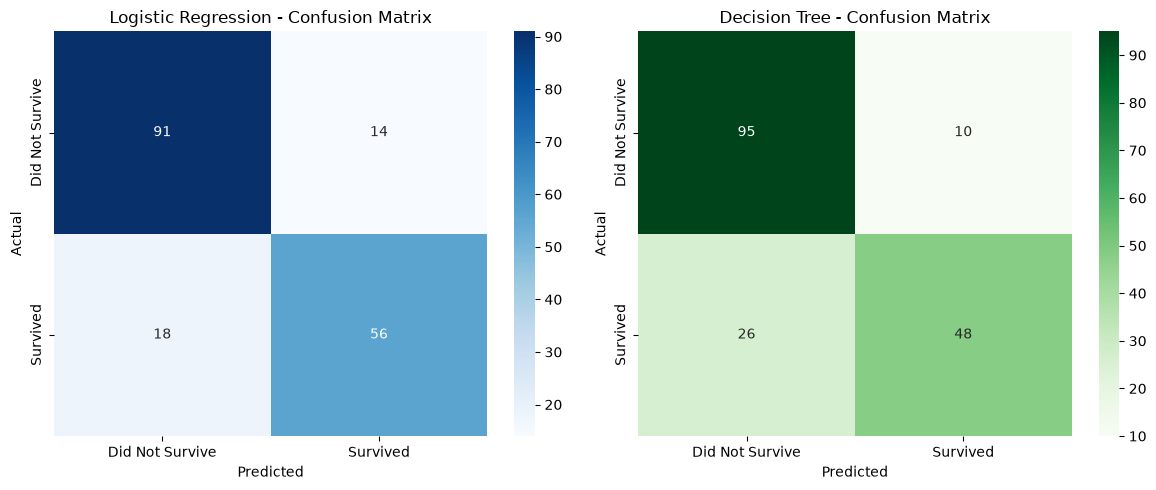

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, log_predictions)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_tree = confusion_matrix(y_test, tree_predictions)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
